In [7]:
import pandas as pd

df = pd.read_csv('../data/employee_attrition_clean.csv')  

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Features = ['Monthly_Income', 'Years_At_Company', 'Performance_Score', 'Age']
scaler = StandardScaler()
Features_Scaled = scaler.fit_transform(df[Features])

In [9]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Kmeans features'] = kmeans.fit_predict(Features_Scaled)
print(df['Kmeans features'].shape)
print("\n")
print(df['Kmeans features'].value_counts())

(970,)


Kmeans features
0    705
1    265
Name: count, dtype: int64


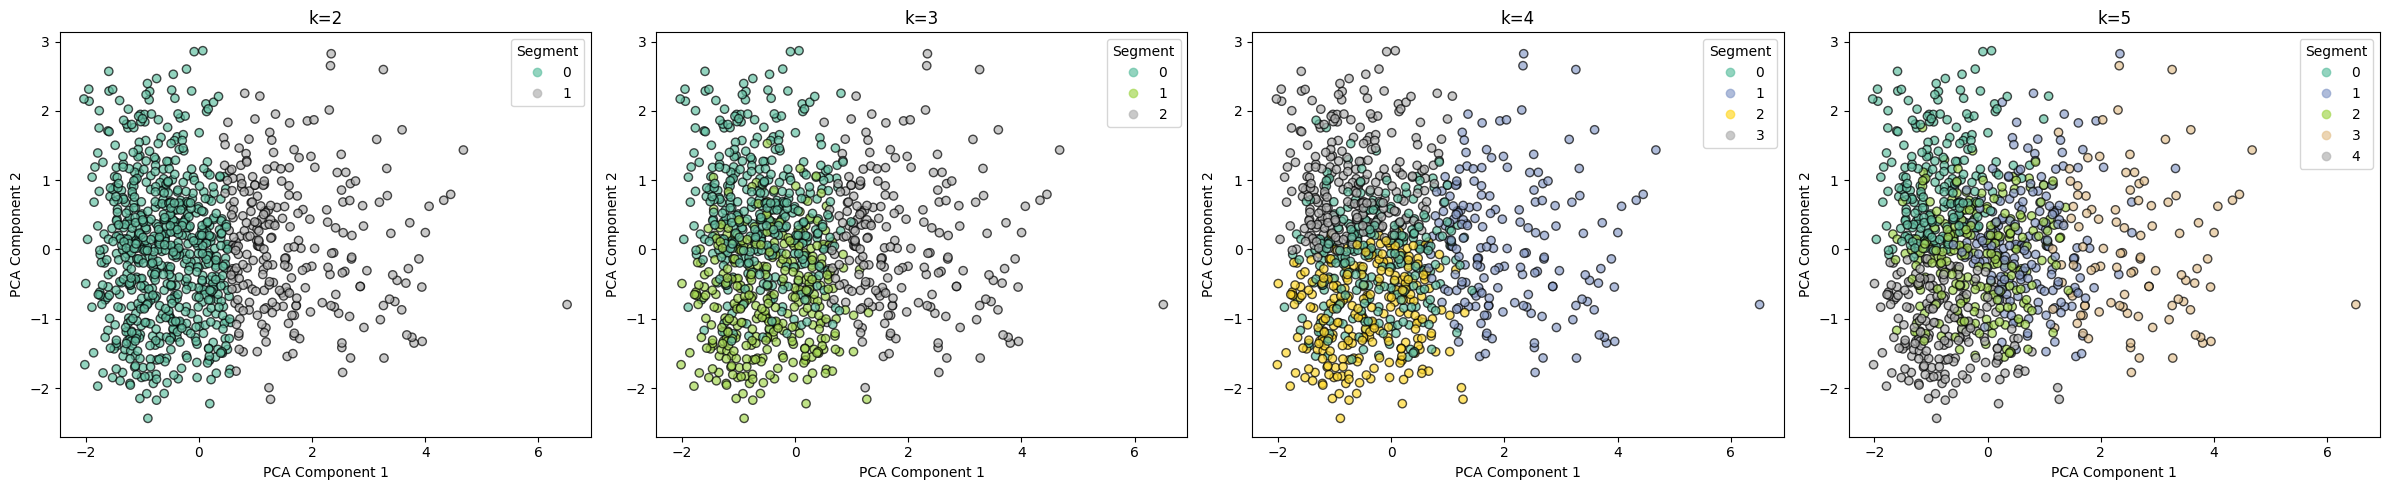

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def plot_clusters_across_k(data_scaled, k_values=[2, 3, 4, 5], random_state=42):
    pca = PCA(n_components=2)
    coords = pca.fit_transform(data_scaled)

    n = len(k_values)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]  

    for ax, k in zip(axes, k_values):
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = kmeans.fit_predict(data_scaled)

        scatter = ax.scatter(coords[:, 0], coords[:, 1],
                              c=labels, cmap='Set2', alpha=0.7, edgecolors='k')
        ax.set_title(f'k={k}')
        ax.set_xlabel('PCA Component 1')
        ax.set_ylabel('PCA Component 2')
        ax.legend(*scatter.legend_elements(), title='Segment', loc='best')

    plt.tight_layout()
    plt.show()


plot_clusters_across_k(Features_Scaled, k_values=[2, 3, 4, 5])



Tested K = 2 , 3 , 4 , 5 clusters and compared them visually PCA Projection 
At k = 2 the two segment show the clearest sepration with minimal overlap
as k increase (3,4,5) the clusters start overlapping 

Chosen: k = 2 